## 1. Import Libraries and Generate Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)

# Generate synthetic data
n = 100
x = np.random.uniform(0, 10, n)
y = 3 * x + 5 + np.random.normal(0, 5, n)

## 2. Compute Basic Statistics and Fit Linear Regression

In [2]:
# Basic stats
print("Mean of x:", round(np.mean(x), 2))
print("Mean of y:", round(np.mean(y), 2))
print("Correlation:", round(np.corrcoef(x, y)[0,1], 2))

# Linear regression (manual formula)
slope = np.cov(x, y, bias=True)[0,1] / np.var(x)
intercept = np.mean(y) - slope * np.mean(x)

print("Slope:", round(slope, 2))
print("Intercept:", round(intercept, 2))

Mean of x: 4.73
Mean of y: 20.15
Correlation: 0.86
Slope: 2.97
Intercept: 6.11


## 3. Visualize the Results

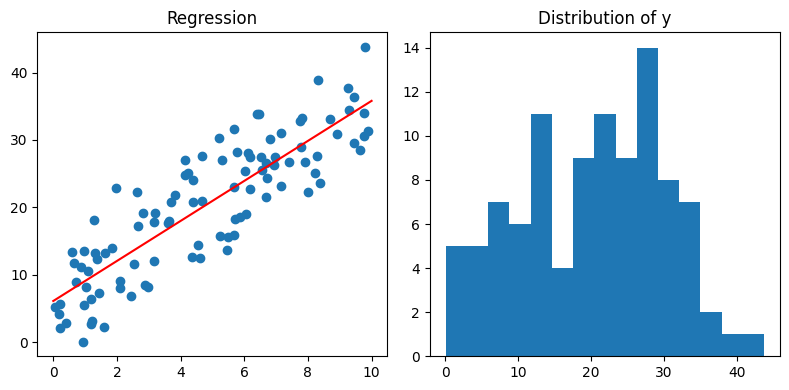

In [3]:
# Regression line
x_line = np.linspace(0, 10, 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.scatter(x, y)
plt.plot(x_line, y_line, color='red')
plt.title("Regression")

plt.subplot(1,2,2)
plt.hist(y, bins=15)
plt.title("Distribution of y")

plt.tight_layout()
plt.show()

In [4]:
!pip freeze

a2wsgi==1.10.10
aiohappyeyeballs==2.6.1
aiohttp==3.13.1
aiosignal==1.4.0
aiosmtplib==5.1.0
aiosqlite==0.21.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.8.0
apache-airflow==3.1.8
apache-airflow-core==3.1.8
apache-airflow-providers-common-compat==1.14.2
apache-airflow-providers-common-io==1.7.2
apache-airflow-providers-common-sql==1.34.0
apache-airflow-providers-smtp==2.4.4
apache-airflow-providers-standard==1.12.2
apache-airflow-task-sdk==1.1.8
argcomplete==3.6.3
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
args==0.1.0
arrow==1.3.0
asgiref==3.11.1
asn1crypto==1.5.1
asttokens==3.0.0
async-lru==2.0.5
attrs==25.1.0
babel==2.17.0
beautifulsoup4==4.13.3
black==25.1.0
bleach==6.2.0
blinker==1.9.0
boto3==1.35.80
botocore==1.35.80
cachetools==5.5.1
cadwyn==5.4.6
certifi==2025.10.5
cffi==2.0.0
charset-normalizer==3.4.1
click==8.3.2
clint==0.5.1
colorama==0.4.6
colorlog==6.10.1
comm==0.2.2
contourpy==1.3.1
cron_descriptor==2.0.8
croniter==6.2.2
cryptogr

In [5]:
!pip install


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\sonuf\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip
ERROR: You must give at least one requirement to install (see "pip help install")


In [6]:
import pandas as pd

df = pd.read_csv("customers.csv")
df.head()

,id,first_name,last_name,email,gender,ip_address
0,1,Jennie,Chumley,jchumley0@ftc.gov,Female,231.191.248.6
1,2,Zacharie,Overal,zoveral1@slideshare.net,Male,55.83.34.131
2,3,Allard,Barmby,abarmby2@timesonline.co.uk,Male,128.35.86.60
3,4,Laurette,Dutt,ldutt3@reference.com,Female,250.143.114.86
4,5,Hansiain,Strowger,hstrowger4@hostgator.com,Male,20.213.72.51


In [7]:
%%sql -r dataframe_3
CREATE OR REPLACE DATABASE DEMO_DB;
CREATE OR REPLACE SCHEMA DEMO_SCHEMA;

USE DATABASE DEMO_DB;
USE SCHEMA DEMO_SCHEMA;

CREATE OR REPLACE TABLE CUSTOMERS (
    id INT,
    first_name STRING,
    last_name STRING,
    email STRING,
    gender STRING,
    ip_address STRING
);

INSERT INTO CUSTOMERS (id, first_name, last_name, email, gender, ip_address)
VALUES
(1, 'Jennie', 'Chumley', 'jchumley0@ftc.gov', 'Female', '231.191.248.6'),
(2, 'Zacharie', 'Overal', 'zoveral1@slideshare.net', 'Male', '55.83.34.131'),
(3, 'Allard', 'Barmby', 'abarmby2@timesonline.co.uk', 'Male', '128.35.86.60'),
(4, 'Laurette', 'Dutt', 'ldutt3@reference.com', 'Female', '250.143.114.86'),
(5, 'Hansiain', 'Strowger', 'hstrowger4@hostgator.com', 'Male', '20.213.72.51');

UsageError: Cell magic `%%sql` not found.


In [ ]:
%%sql -r dataframe_4
SELECT * FROM CUSTOMERS;

In [ ]:
dataframe_4.head()

In [ ]:
import pandas as pd

# Copy the SQL output dataframe
df = dataframe_4.copy()

# Select relevant columns
df = df[[
    "FIRST_NAME",
    "LAST_NAME",
    "EMAIL",
    "GENDER",
    "IP_ADDRESS"
]]

# Example processing: Create a column for first name length category
df["NAME_LENGTH_TIER"] = pd.cut(
    df["FIRST_NAME"].str.len(),
    bins=[0, 4, 6, float("inf")],
    labels=["Short", "Medium", "Long"]
)

# Example processing: Extract email domain
df["EMAIL_DOMAIN"] = df["EMAIL"].str.split("@").str[1]

# Show the first few rows to make it available for SQL
df.head()

In [ ]:
%%sql -r dataframe_5
SELECT
    NAME_LENGTH_TIER,
    EMAIL_DOMAIN,
    COUNT(*) AS CUSTOMER_COUNT
FROM {{df}}
GROUP BY NAME_LENGTH_TIER, EMAIL_DOMAIN
ORDER BY NAME_LENGTH_TIER, CUSTOMER_COUNT DESC;

In [ ]:
%%sql -r dataframe_6
CREATE TABLE CUSTOMER_TRANSFORMED AS SELECT * FROM {{dataframe_5}};

In [ ]:
%%sql -r dataframe_7
SELECT * FROM CUSTOMER_TRANSFORMED;

In [ ]:
from snowflake.snowpark.context import get_active_session
from snowflake.snowpark.functions import col, length, split, lit

# Get the active Snowpark session
session = get_active_session()

# Load the CUSTOMERS table into a Snowpark DataFrame
customers_df = session.table("CUSTOMERS")

# Process the data:
# - Compute length of the first name
# - Split the email by "@" using lit("@") and extract the domain
processed_df = (
    customers_df
    .with_column("FIRST_NAME_LENGTH", length(col("FIRST_NAME")))
    .with_column(
        "EMAIL_DOMAIN_ARRAY",
        split(col("EMAIL"), lit("@"))  # lit("@") is required for a string literal
    )
    .with_column(
        "EMAIL_DOMAIN",
        col("EMAIL_DOMAIN_ARRAY")[1]  # pick the second element from the split array
    )
    .select(
        "FIRST_NAME", "LAST_NAME", "EMAIL", "FIRST_NAME_LENGTH", "EMAIL_DOMAIN"
    )
)

# Show the result (first 5 rows as pandas DataFrame)
processed_df.limit(5).to_pandas()

In [ ]:
%%sql -r dataframe_1
DROP DATABASE DEMO_DB;